# Phase 2A: basic within-frame geometry

Descriptive implementation validation in native StatsBomb 120 × 80 units. The eight locked metric families emit nine numeric outputs. Each original frame has six literal subset/goalkeeper variants. These are partial visible records, not full-team or tactical measurements.

Run `python scripts/geometry_diagnostics.py` from the repository root to generate the derived tables. This notebook reads compact summaries and rejects an unknown or different source revision. All geometry and summaries are computed in the reusable package; no raw records are saved.

In [1]:
%matplotlib inline
from pathlib import Path
from IPython.display import display
from leverkusen.spatial.diagnostics import read_geometry_diagnostics
from leverkusen.visualization.geometry import (
    plot_distributions, plot_by_valid_points, plot_goalkeeper_sensitivity,
)

root = Path.cwd() if (Path.cwd() / 'config/project.yaml').is_file() else Path.cwd().parent
summaries = read_geometry_diagnostics(root / 'outputs/diagnostics')
display(summaries['inventory'])
display(summaries['match_summary'])

,original_frames,variant_rows,matches_with_frames,statsbomb_revision
0,118581,711486,34,533862946a73608c134d18b78226b6371ce7173c


,match_id,events,original_frames,variant_rows,frames_load_status,frames_load_error,statsbomb_revision,source_base_url,retrieved_at_utc
0,3895302,4223,3525,21150,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:47.318608+00:00
1,3895292,3843,3195,19170,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:58.468962+00:00
2,3895333,3549,2950,17700,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:09.782972+00:00
3,3895340,3315,2847,17082,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:20.610007+00:00
4,3895348,4133,3562,21372,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:33.772695+00:00
5,3895286,3894,3434,20604,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:48.857965+00:00
6,3895220,4258,3757,22542,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:02.026975+00:00
7,3895250,3826,3410,20460,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:14.963602+00:00
8,3895266,4104,3623,21738,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:28.007176+00:00
9,3895275,3909,3341,20046,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:40.710549+00:00


## Availability and status

Count is zero for known-empty selections; an unavailable frame has NA measurements. Every other NA is accompanied by a metric-specific reason. Centroid components share one status rule. The tables retain all rows, including actor ambiguity and low visible-area coverage. This is an inventory of diagnostic measurements; the registry's later primary-comparison ambiguity policy is not applied here.

In [2]:
display(summaries['metric_summary'])
display(summaries['metric_status'])
display(summaries['anomalies'])

,selected_subset,goalkeeper_policy,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,visible_player_count,118581,118581,0,0.000000,16.471290,3.120971,1.000000,11.000000,14.000000,17.000000,19.000000,20.000000,22.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,118581,118581,0,0.000000,63.806991,26.356173,3.099943,18.089736,43.568488,66.138246,85.053678,103.246848,118.677691,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,118581,118581,0,0.000000,40.174659,11.653331,3.205394,21.231619,31.241141,40.167044,49.157679,58.922186,75.576509,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,118581,118581,0,0.000000,47.464932,11.092361,0.000000,28.990084,39.955072,47.524532,55.377362,65.637942,81.286486,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,118581,118581,0,0.000000,33.689701,7.986431,0.000000,21.924168,28.563324,32.954542,38.021937,47.994070,110.967021,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,included,convex_hull_area,118581,118574,7,0.005903,1031.928057,393.677325,2.573681,430.826141,757.614800,1009.966918,1276.996848,1700.748408,4304.400473,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,mean_pairwise_distance,118581,118580,1,0.000843,21.272467,3.969144,5.299529,14.244654,18.825975,21.497648,23.974184,27.356049,39.737569,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,median_pairwise_distance,118581,118580,1,0.000843,20.140406,3.936288,5.012747,13.177037,17.778163,20.344390,22.745449,26.220053,39.547351,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,mean_nearest_neighbor_distance,118581,118580,1,0.000843,6.374906,1.568486,1.203826,4.014342,5.323020,6.286875,7.259955,9.107558,25.855086,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,excluded,visible_player_count,118581,118581,0,0.000000,16.071580,3.202193,0.000000,10.000000,14.000000,17.000000,19.000000,20.000000,21.000000,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,metric,status,rows,statsbomb_revision
0,all_visible,included,visible_player_count,ok,118581,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,ok,118581,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,ok,118581,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,ok,118581,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,ok,118581,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...
89,teammate_false,excluded,mean_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
90,teammate_false,excluded,median_pairwise_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c
91,teammate_false,excluded,median_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
92,teammate_false,excluded,mean_nearest_neighbor_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c


,flag,variant_rows,original_frames,statsbomb_revision
0,coincident_records,198,50,533862946a73608c134d18b78226b6371ce7173c
1,multiple_actor,24,4,533862946a73608c134d18b78226b6371ce7173c
2,out_of_bounds_points,45565,11508,533862946a73608c134d18b78226b6371ce7173c


## Observed distributions

All six variants use shared display bins for each metric. Count is in records; hull area is in squared native units; other values are in native units. Histogram binning sets no visibility threshold.

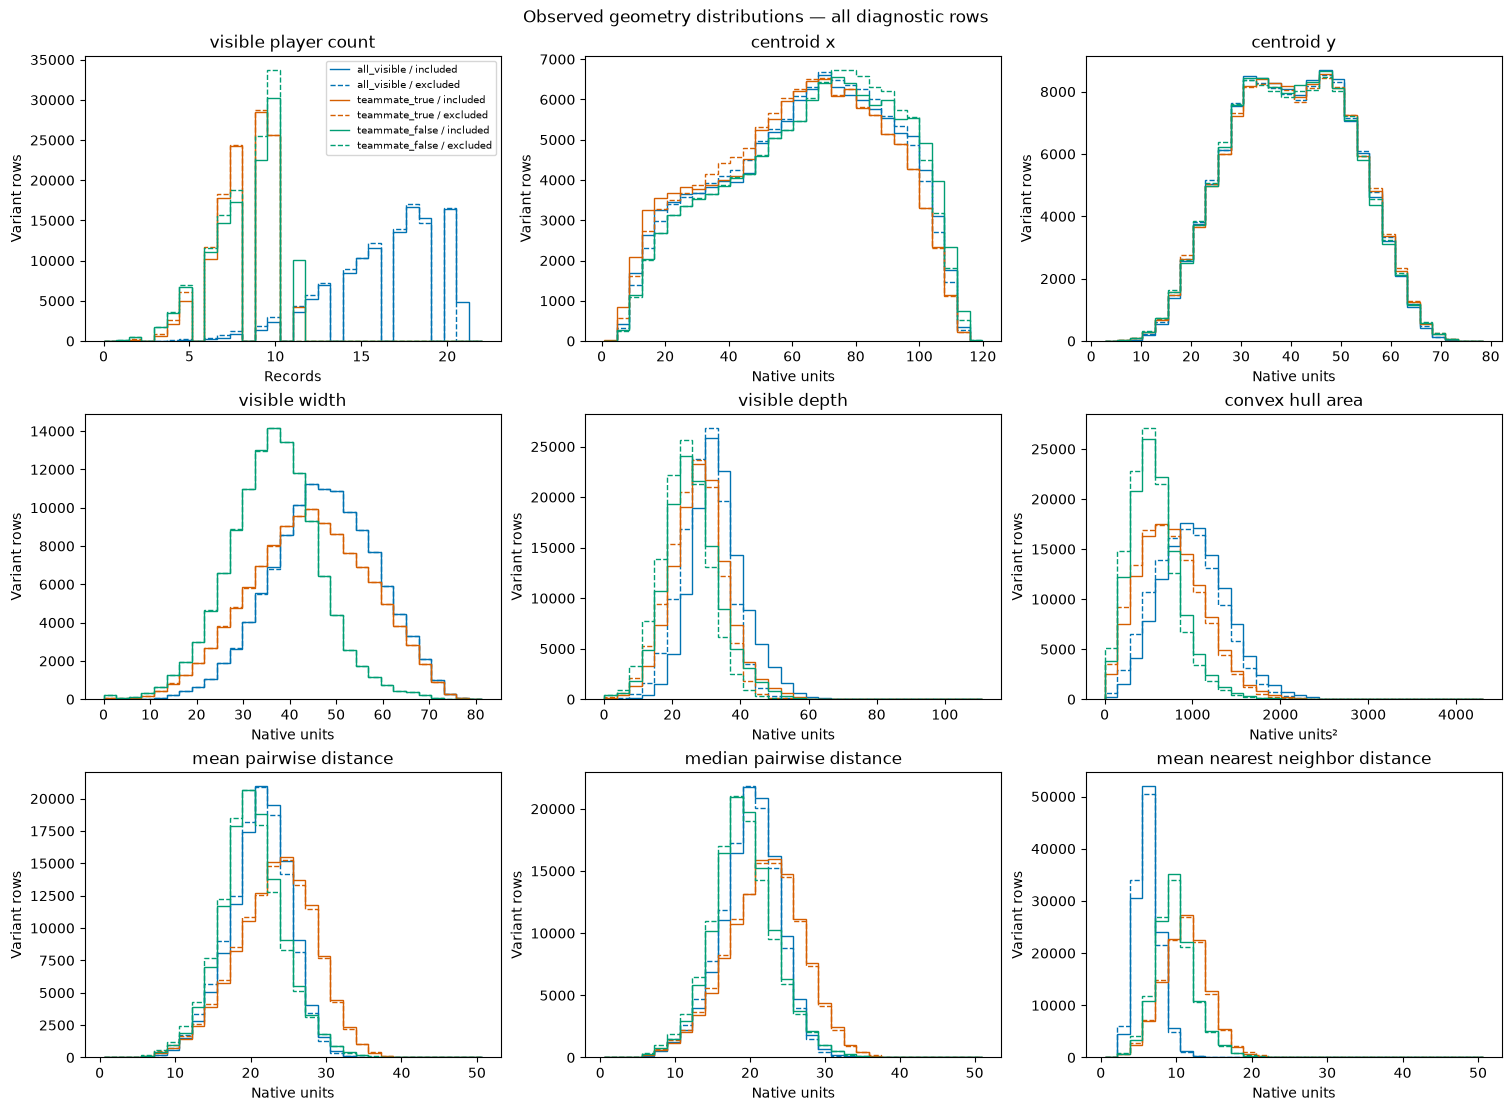

In [3]:
figure = plot_distributions(summaries['histograms'])

## Goalkeeper sensitivity

Differences are **excluded minus included**, paired by match, original frame ordinal and literal subset. `excluded` retains only `keeper=False`. Unknown keeper omissions are reported separately. Tables show all pairs and pairs with at least one record removed. Plot means use the latter group and only jointly defined metric values; consult availability denominators. Different metric minima can make the paired samples differ.

,selected_subset,scope,metric,delta_direction,rows,available,na,na_percent,mean,std,...,p25,median,p75,p95,max,pairs_with_keeper_removal,pairs_with_unknown_keeper_removal,changed_pairs,mean_absolute_delta,statsbomb_revision
0,all_visible,all_pairs,visible_player_count,excluded_minus_included,118581,118581,0,0.000000,-0.399710,0.489910,...,-1.000000,0.000000,0.000000,0.000000,0.000000,47394,0,47394,0.399710,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,all_pairs,centroid_x,excluded_minus_included,118581,118580,1,0.000843,0.045734,0.966287,...,0.000000,0.000000,0.000000,1.921518,12.526461,47394,0,47393,0.556485,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,all_pairs,centroid_y,excluded_minus_included,118581,118580,1,0.000843,0.002562,0.361687,...,0.000000,0.000000,0.000000,0.610513,7.466498,47394,0,47393,0.176888,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,all_pairs,visible_width,excluded_minus_included,118581,118580,1,0.000843,-0.016687,0.355091,...,0.000000,0.000000,0.000000,0.000000,0.000000,47394,0,556,0.016687,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,all_pairs,visible_depth,excluded_minus_included,118581,118580,1,0.000843,-4.167210,6.489208,...,-8.139859,0.000000,0.000000,0.000000,0.000000,47394,0,45089,4.167210,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,all_pairs,convex_hull_area,excluded_minus_included,118581,118562,19,0.016023,-87.756434,145.908657,...,-146.016491,0.000000,0.000000,0.000000,0.000000,47394,0,46831,87.756434,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,all_pairs,mean_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.335259,0.668195,...,-0.540009,0.000000,0.000000,0.000000,7.396091,47394,0,47387,0.361660,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,all_pairs,median_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.343683,0.776539,...,-0.477361,0.000000,0.000000,0.000000,6.764277,47394,0,45716,0.385460,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,all_pairs,mean_nearest_neighbor_distance,excluded_minus_included,118581,118574,7,0.005903,-0.162221,0.381839,...,-0.306796,0.000000,0.000000,0.014408,14.118107,47394,0,47387,0.204189,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,records_removed,visible_player_count,excluded_minus_included,47394,47394,0,0.000000,-1.000084,0.009187,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,47394,0,47394,1.000084,533862946a73608c134d18b78226b6371ce7173c


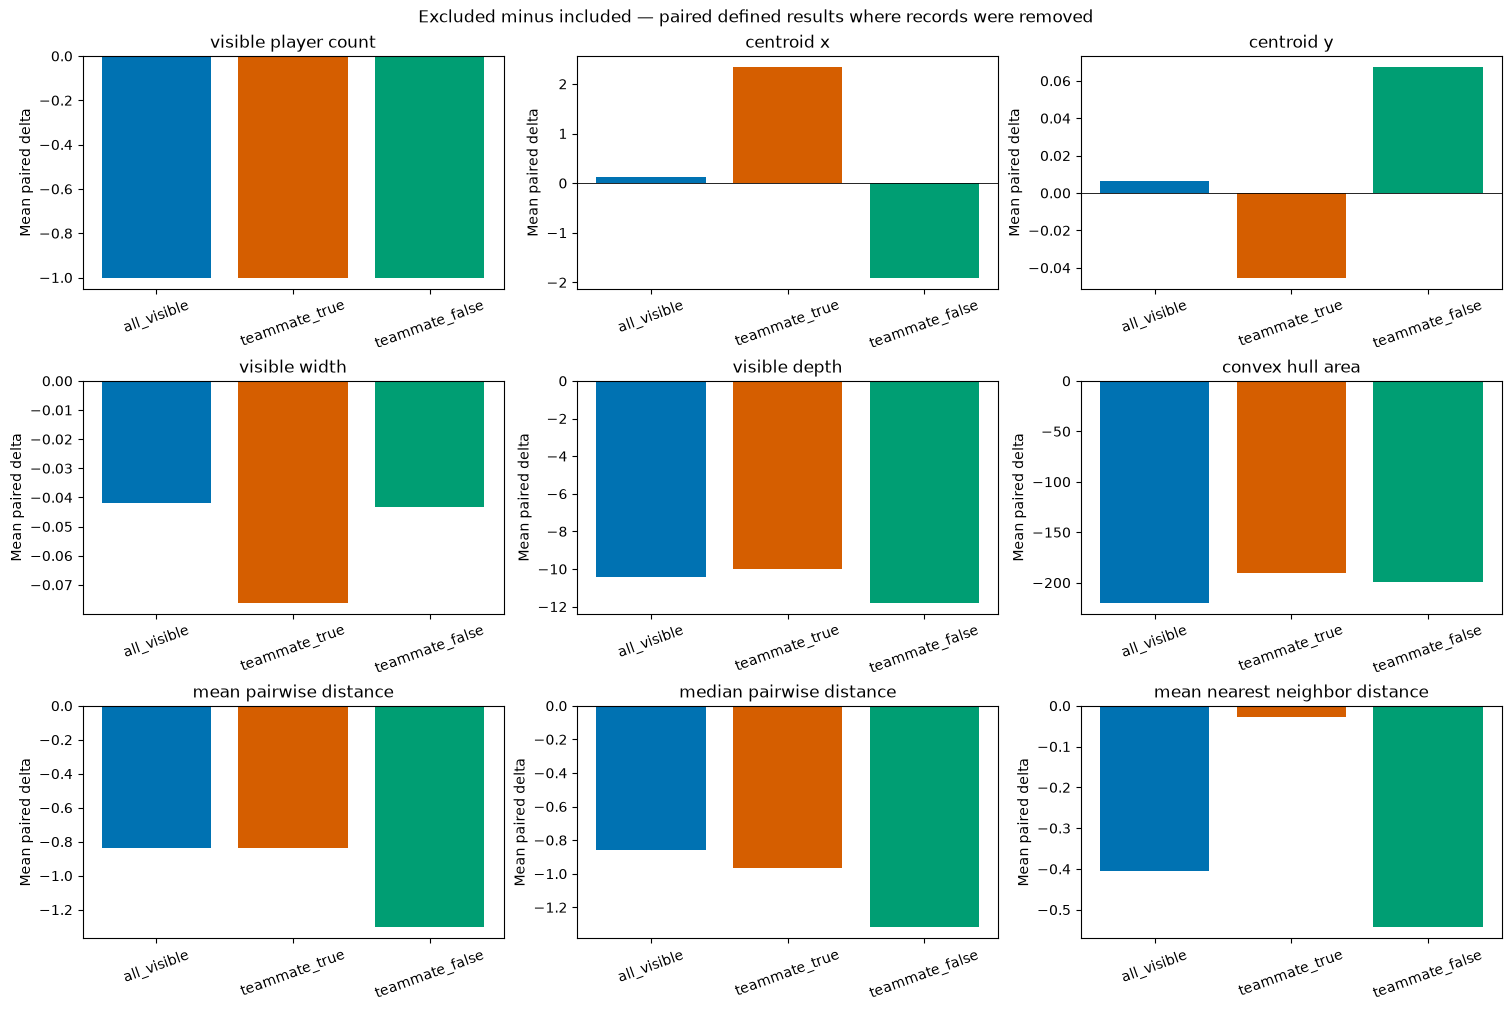

In [4]:
display(summaries['goalkeeper_sensitivity'])
figure = plot_goalkeeper_sensitivity(summaries['goalkeeper_sensitivity'])

## Dependence on selected valid-point count

Strata use the exact number of selected valid records, separately for each subset/keeper variant. Means describe composition and observation differences across strata; they do not establish a full-team shape or tactical effect. The table supplies sample counts and NA rates, including sparse strata.

,selected_subset,goalkeeper_policy,n_valid_points_used,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,1,visible_player_count,1,1,0,0.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,1,centroid_x,1,1,0,0.0,9.100000,NaN,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,1,centroid_y,1,1,0,0.0,36.500000,NaN,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,1,visible_width,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,1,visible_depth,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,teammate_false,excluded,11,visible_depth,30,30,0,0.0,26.368894,13.229105,8.206526,9.291440,15.501970,22.848811,35.267539,52.107770,52.382760,533862946a73608c134d18b78226b6371ce7173c
815,teammate_false,excluded,11,convex_hull_area,30,30,0,0.0,581.724219,443.471777,54.404752,70.872105,138.696868,449.675352,1016.168642,1261.357766,1328.405390,533862946a73608c134d18b78226b6371ce7173c
816,teammate_false,excluded,11,mean_pairwise_distance,30,30,0,0.0,16.530486,7.217471,5.775810,6.300357,8.321684,16.509510,23.108703,25.844235,28.364683,533862946a73608c134d18b78226b6371ce7173c
817,teammate_false,excluded,11,median_pairwise_distance,30,30,0,0.0,15.444811,6.770700,5.105827,5.940909,8.717889,14.378556,21.755108,24.926346,25.215685,533862946a73608c134d18b78226b6371ce7173c


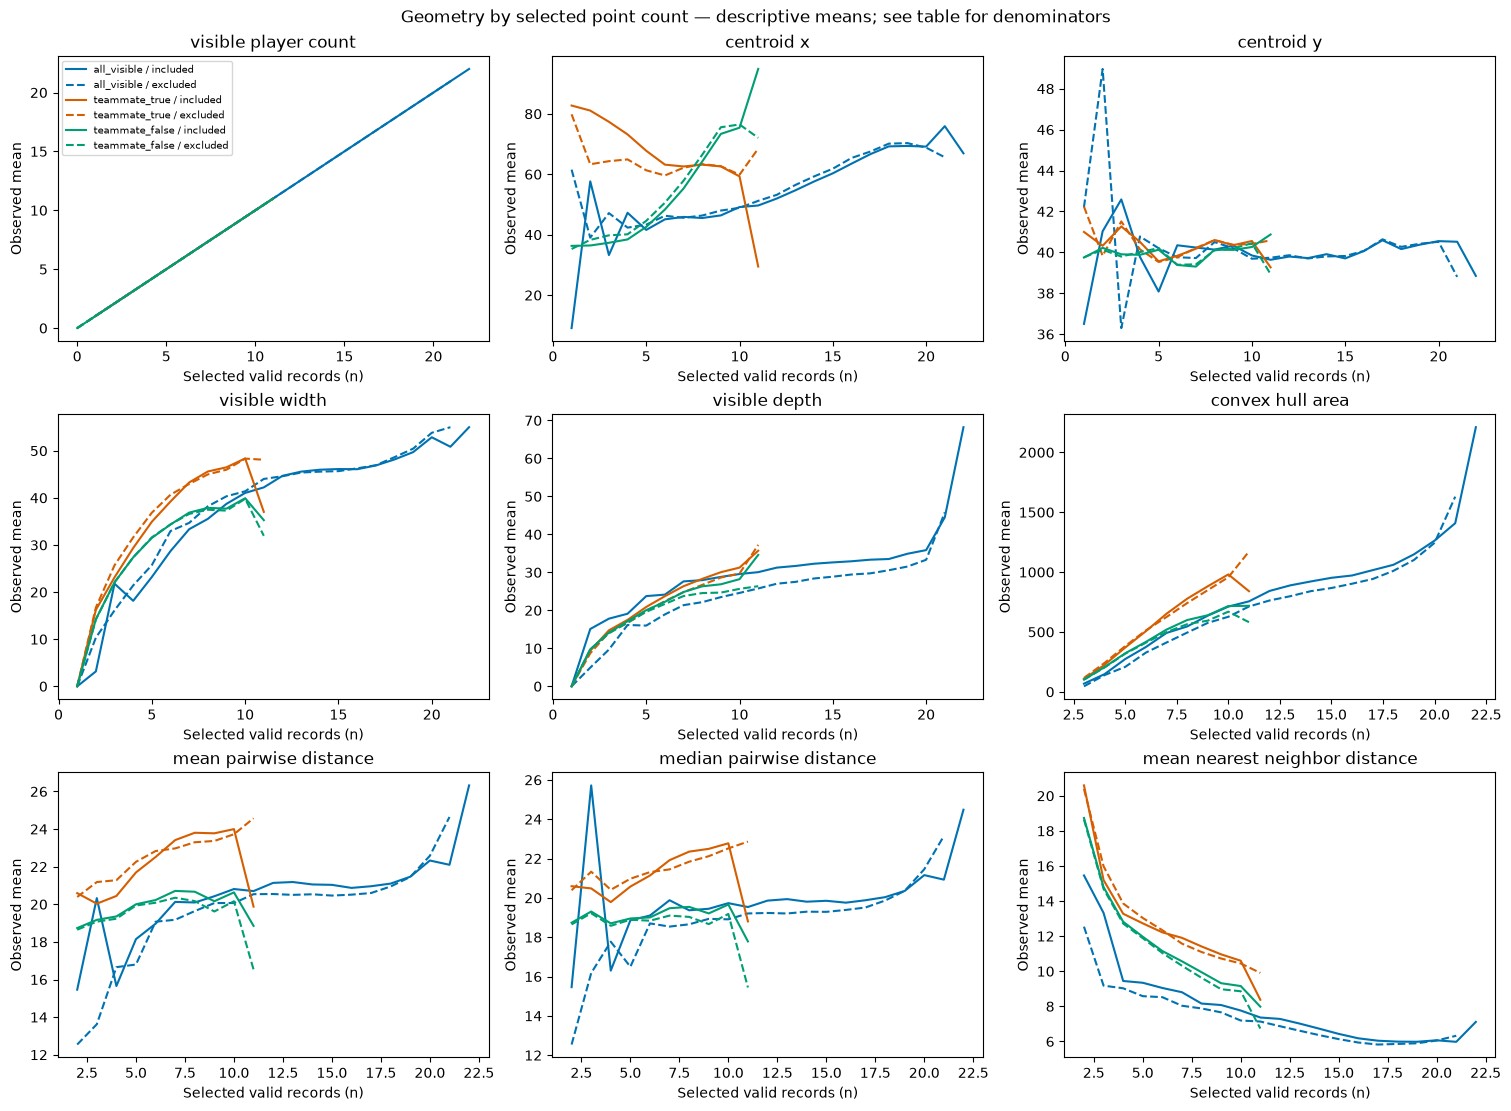

In [5]:
display(summaries['by_valid_points'])
figure = plot_by_valid_points(summaries['by_valid_points'])

## Validation boundary

Coincident records retain their original weights. Multiple/unknown actor statuses are flags, without actor selection or deduplication. Finite out-of-bounds points remain measured and flagged. There is no coordinate flipping, metre conversion, zone assignment, eligibility threshold, sequence construction or later metric here.

Implementation checks and empirical results are recorded in `report/technical_appendix.md`. Representative-frame review, visibility calibration, identity ambiguity and direction-dependent interpretation remain separate work.

# Phase 2B-1 — Observation Sensitivity

Bounded descriptive analysis of the existing Phase 2A frame-variant table. All six literal subset/keeper variants and all recorded quality flags remain in the diagnostic population. No geometry is recomputed and no eligibility or calibration decision is made.

Generate the compact summaries from the repository root with `python scripts/observation_sensitivity.py`. The run summary records the input CSV hash and source revision. Shared visible-area quintiles are display/grouping boundaries, with each original frame contributing once; they are not proposed thresholds.

In [2]:
from leverkusen.spatial.observation_sensitivity import read_observation_sensitivity
from leverkusen.visualization.observation_sensitivity import (
    plot_count_dependence, plot_visible_area_dependence, plot_keeper_deltas,
)

sensitivity = read_observation_sensitivity(root / 'outputs/diagnostics')
display(sensitivity['run_summary'])

,source_file,source_sha256,original_frames,variant_rows,matches,requested_area_bins,effective_area_bins,generated_at_utc,statsbomb_revision
0,phase2a_frame_geometry.csv,a6af9ceb6182c02159de78c8e57ad5ecda635d47e282ee...,118581,711486,34,5,5,2026-09-08T00:44:34.799638+00:00,533862946a73608c134d18b78226b6371ce7173c


## 1. Selected valid-point-count dependence

Each row describes one exact n, subset, keeper policy and existing metric. `frame_count` is the group inventory; `denominator` is the count of defined values used for its statistics; `na_count` is their difference. Standard deviation uses ddof=1 and quantiles use pandas linear interpolation. Undefined hull groups retain their counts with NA statistics.

The figure shows medians for five major metrics across every observed n. The compact CSV includes median pairwise distance as well. Sparse endpoint strata remain in the tables and figure; no minimum reliable n is selected.

,selected_subset,goalkeeper_policy,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,118581,118581,0,16.071580,17.0,3.202193,10.0,14.0,19.0,20.0,0,21,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,118581,118581,0,16.471290,17.0,3.120971,11.0,14.0,19.0,20.0,1,22,533862946a73608c134d18b78226b6371ce7173c
2,teammate_false,excluded,118581,118581,0,8.041701,9.0,1.878042,4.0,7.0,10.0,10.0,0,11,533862946a73608c134d18b78226b6371ce7173c
3,teammate_false,included,118581,118581,0,8.247257,9.0,1.999297,4.0,7.0,10.0,11.0,0,11,533862946a73608c134d18b78226b6371ce7173c
4,teammate_true,excluded,118581,118581,0,8.029878,8.0,1.660417,5.0,7.0,9.0,10.0,0,11,533862946a73608c134d18b78226b6371ce7173c
5,teammate_true,included,118581,118581,0,8.224033,8.0,1.652575,5.0,7.0,10.0,10.0,1,11,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,n_valid_points_used,metric,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,0,visible_width,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,0,visible_depth,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,0,convex_hull_area,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,0,mean_pairwise_distance,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,0,median_pairwise_distance,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,teammate_true,included,11,visible_depth,4278,4278,0,35.695538,35.828642,12.968642,15.367521,25.383645,45.911408,55.973472,6.684371,79.262158,533862946a73608c134d18b78226b6371ce7173c
542,teammate_true,included,11,convex_hull_area,4278,4278,0,840.475777,694.611744,594.914514,152.546916,383.360735,1123.086801,2096.786542,41.073676,3122.356016,533862946a73608c134d18b78226b6371ce7173c
543,teammate_true,included,11,mean_pairwise_distance,4278,4278,0,19.875855,19.301875,7.483896,8.846396,14.177797,24.267359,34.106906,5.448809,42.891658,533862946a73608c134d18b78226b6371ce7173c
544,teammate_true,included,11,median_pairwise_distance,4278,4278,0,18.803640,18.210926,7.399778,8.107611,13.398992,23.008832,32.941768,4.136146,44.912695,533862946a73608c134d18b78226b6371ce7173c


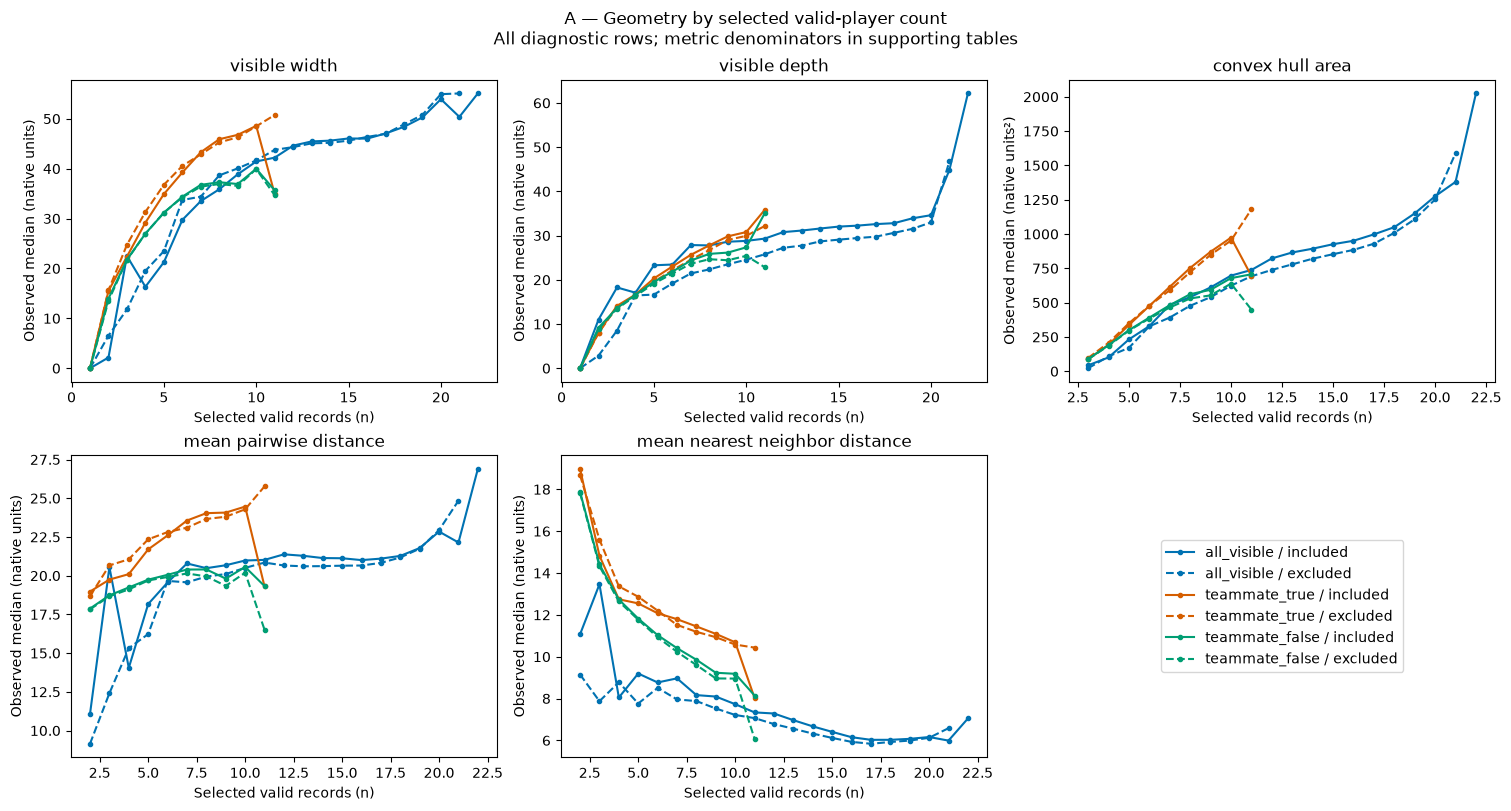

In [3]:
display(sensitivity['player_count_context'])
display(sensitivity['metric_by_valid_point_count'])
figure = plot_count_dependence(sensitivity['metric_by_valid_point_count'])

## 2. Visible-area dependence

The same five coverage bins apply to every variant. Intervals are right closed, with the minimum included in the first bin; ties stay together. Duplicate quantile edges collapse deterministically. Missing coverage has a separate unavailable category if present. Exact bounds and original-frame denominators are shown below.

The joint table describes **n** within each coverage bin: its mean, median, standard deviation and quantiles are selected record counts. These summaries show marginal observed dependence; coverage and player-count relationships are not independently adjusted.

,visible_area_bin,bin_order,lower,upper,lower_inclusive,upper_inclusive,requested_bins,effective_bins,original_frame_count,statsbomb_revision
0,B1,1,0.045220,0.216823,True,True,5,5,23718,533862946a73608c134d18b78226b6371ce7173c
1,B2,2,0.216823,0.265017,False,True,5,5,23715,533862946a73608c134d18b78226b6371ce7173c
2,B3,3,0.265017,0.318402,False,True,5,5,23717,533862946a73608c134d18b78226b6371ce7173c
3,B4,4,0.318402,0.383159,False,True,5,5,23716,533862946a73608c134d18b78226b6371ce7173c
4,B5,5,0.383159,0.861461,False,True,5,5,23715,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,visible_area_bin,metric,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,B1,visible_width,23718,23717,1,38.571426,39.219328,9.280781,22.362169,32.393397,45.085652,52.667951,0.000000,76.679790,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,B1,visible_depth,23718,23717,1,24.872763,25.008745,6.617939,13.742660,20.310096,29.621830,35.341060,0.000000,63.277223,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,B1,convex_hull_area,23718,23713,5,618.297003,593.658056,277.439357,213.250993,405.684823,814.620906,1100.906971,1.156072,2720.715833,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,B1,mean_pairwise_distance,23718,23713,5,17.550792,17.722209,3.900115,11.014586,14.715683,20.426390,23.623926,4.424395,34.992962,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,B1,median_pairwise_distance,23718,23713,5,16.513609,16.759154,3.964004,9.751719,13.655944,19.433974,22.634027,3.267774,35.735121,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,teammate_true,included,B5,visible_depth,23715,23715,0,34.009886,32.894815,8.473227,21.747399,28.528069,38.371173,50.454901,0.000000,85.028597,533862946a73608c134d18b78226b6371ce7173c
176,teammate_true,included,B5,convex_hull_area,23715,23702,13,1098.085017,1088.548157,387.087826,501.661673,826.680524,1333.287077,1756.639648,0.198937,3122.356016,533862946a73608c134d18b78226b6371ce7173c
177,teammate_true,included,B5,mean_pairwise_distance,23715,23711,4,26.727360,27.124532,4.360905,19.026106,23.873847,29.725918,33.469007,8.728171,42.891658,533862946a73608c134d18b78226b6371ce7173c
178,teammate_true,included,B5,median_pairwise_distance,23715,23711,4,25.261960,25.442885,4.360397,17.758265,22.435065,28.172601,32.161779,7.013796,44.912695,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,visible_area_bin,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,B1,23718,23718,0,14.649127,15.0,2.998911,9.0,13.0,17.0,19.0,0,21,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,B2,23715,23715,0,15.543454,16.0,3.095088,10.0,14.0,18.0,20.0,2,21,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,B3,23717,23717,0,15.938103,17.0,3.206182,10.0,14.0,18.0,20.0,1,21,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,B4,23716,23716,0,16.524034,17.0,3.150851,10.0,15.0,19.0,20.0,2,21,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,B5,23715,23715,0,17.703352,19.0,2.702521,12.0,16.0,20.0,20.0,4,21,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,included,B1,23718,23718,0,15.146555,15.0,2.987956,10.0,13.0,17.0,20.0,1,22,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,B2,23715,23715,0,15.911406,16.0,3.034624,10.0,14.0,18.0,20.0,3,22,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,B3,23717,23717,0,16.329047,17.0,3.091837,10.0,14.0,19.0,20.0,2,22,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,B4,23716,23716,0,16.924439,18.0,3.048837,11.0,15.0,19.0,21.0,3,22,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,included,B5,23715,23715,0,18.045161,19.0,2.634560,13.0,17.0,20.0,21.0,4,22,533862946a73608c134d18b78226b6371ce7173c


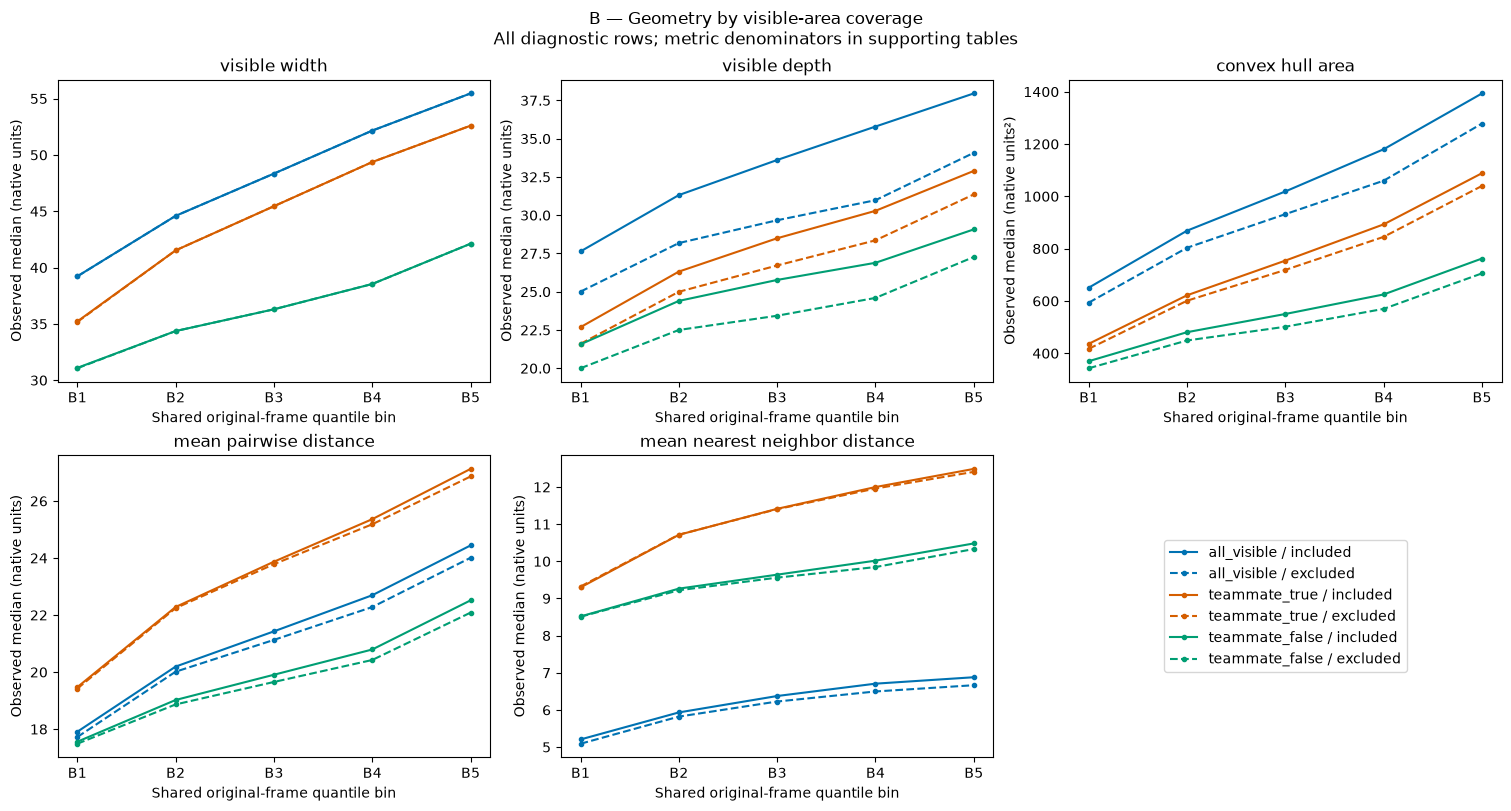

In [4]:
display(sensitivity['visible_area_bins'])
display(sensitivity['metric_by_visible_area'])
display(sensitivity['visibility_vs_player_count'])
figure = plot_visible_area_dependence(
    sensitivity['metric_by_visible_area'], sensitivity['visible_area_bins'],
)

## 3. Goalkeeper sensitivity

Deltas are excluded minus included, paired on match, original frame ordinal and literal subset. Only jointly defined metric values enter comparisons. Tables distinguish `all_frames` and `keeper_removed` scopes, retain total frame counts and NA-pair counts, and disclose unknown keeper omissions separately. The latter scope requires an actual `keeper=True` record removal. No keeper convention is chosen.

`proportion_numerically_changed` uses jointly defined pairs as its denominator and exact nonzero deltas, without a tolerance. Figure C shows the median, interquartile interval and p05–p95 interval for both scopes. These are descriptive distribution intervals, not confidence intervals.

,selected_subset,scope,metric,delta_direction,total_frames,keeper_removed_frames,unknown_keeper_removed_frames,keeper_removal_status_unavailable_frames,scope_frames,jointly_defined_count,...,p05,p25,p75,p95,min,max,mean_absolute_delta,numerically_changed_count,proportion_numerically_changed,statsbomb_revision
0,all_visible,all_frames,visible_width,excluded_minus_included,118581,47394,0,0,118581,118580,...,0.000000,0.000000,0.000000,0.000000,-22.311836,0.000000,0.016687,556,0.004689,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,all_frames,visible_depth,excluded_minus_included,118581,47394,0,0,118581,118580,...,-17.678806,-8.139859,0.000000,0.000000,-54.652932,0.000000,4.167210,45089,0.380241,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,all_frames,convex_hull_area,excluded_minus_included,118581,47394,0,0,118581,118562,...,-400.143918,-146.016491,0.000000,0.000000,-1679.012415,0.000000,87.756434,46831,0.394992,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,all_frames,mean_pairwise_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-1.672510,-0.540009,0.000000,0.000000,-20.411957,7.396091,0.361660,47387,0.399641,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,all_frames,median_pairwise_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-1.832342,-0.477361,0.000000,0.000000,-30.388413,6.764277,0.385460,45716,0.385548,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,all_frames,mean_nearest_neighbor_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-0.835646,-0.306796,0.000000,0.014408,-10.129471,14.118107,0.204189,47387,0.399641,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,keeper_removed,visible_width,excluded_minus_included,118581,47394,0,0,47394,47393,...,0.000000,0.000000,0.000000,0.000000,-22.311836,0.000000,0.041751,556,0.011732,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,keeper_removed,visible_depth,excluded_minus_included,118581,47394,0,0,47394,47393,...,-20.677780,-14.627011,-5.633739,-0.066048,-54.652932,0.000000,10.426598,45089,0.951385,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,keeper_removed,convex_hull_area,excluded_minus_included,118581,47394,0,0,47394,47375,...,-511.783046,-307.104391,-102.049241,-22.256829,-1679.012415,0.000000,219.621707,46831,0.988517,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,keeper_removed,mean_pairwise_distance,excluded_minus_included,118581,47394,0,0,47394,47387,...,-2.207617,-1.251513,-0.303415,0.240787,-20.411957,7.396091,0.904963,47387,1.000000,533862946a73608c134d18b78226b6371ce7173c


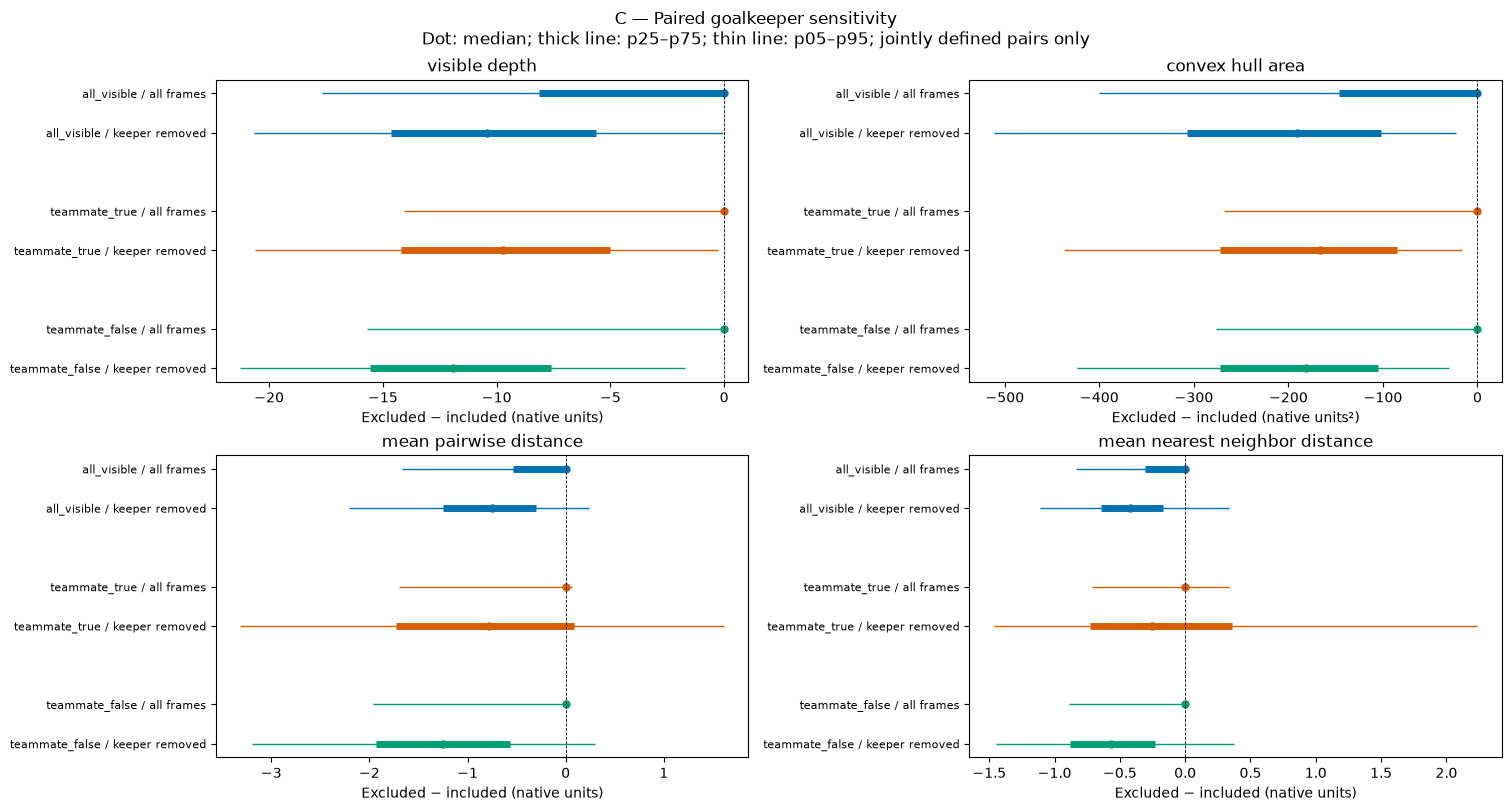

In [5]:
display(sensitivity['goalkeeper_sensitivity'])
figure = plot_keeper_deltas(sensitivity['goalkeeper_sensitivity'])

## 4. Short diagnostic summary

With keepers included, all-visible strata at n=14 and n=19 have median width 45.62 and 50.28, hull area 893.32 and 1,150.46, and mean nearest-neighbor distance 6.67 and 6.07. Their exact-n frame counts are 8,493 and 15,263. The full tables retain both policies and literal teammate subsets.

Across the lowest and highest visible-area quintiles, all-visible included median hull area is 650.77 and 1,393.44; median mean pairwise distance is 17.91 and 24.44. Mean selected n is 15.15 and 18.05. The two bins contain 23,718 and 23,715 original frames. Higher coverage is associated with higher values of all six summarized metrics in these endpoint comparisons across all variants.

Among all-visible frames where a keeper was removed, mean paired depth delta is −10.43 (47,393 defined pairs) and hull delta is −219.62 (47,375 pairs). Width changes in 1.17% of affected defined pairs. The teammate_true mean nearest-neighbor delta is −0.028, while its mean absolute delta is 0.856 (23,006 pairs), indicating variation in both directions.

Player count and coverage co-vary. Nearest-neighbor medians decrease across the selected n comparisons but increase across the coverage endpoints. These marginal associations and paired sensitivities require human review before calibration. They do not establish a tactical effect or justify a threshold. Detailed out-of-bounds, boundary/edge, coincidence, representative-frame and orientation work remains deferred.